#CONVOLUTIONAL NEURAL NETWORKS
---

##0.REFERENCE

**Notebook title: Convolutional Neural Networks for Fashion-MNIST Image Classification**

**Introduction**

Fashion-MNIST is an excellent dataset for teaching convolutional neural networks because it occupies the perfect middle ground between simplicity and realism. The original MNIST handwritten digits dataset is historically important, but it is visually too simple for demonstrating why convolution matters. Fashion-MNIST keeps the same convenient format of 28 by 28 grayscale images, but replaces digits with clothing items such as shirts, trousers, dresses, coats, sandals, sneakers, bags, and ankle boots. This makes the classification task more visually meaningful while remaining small enough to run easily in Google Colab.

The purpose of this notebook is to teach the basic logic of convolutional neural networks. In the previous digits example, we used a fully connected deep neural network. That model treated every pixel as an independent input feature. It did not know that neighboring pixels belong to local visual structures. A fully connected network can still learn useful patterns, but it ignores the spatial organization of images. Convolutional neural networks solve this problem by looking at local regions of the image and learning small filters that detect visual patterns such as edges, curves, corners, textures, and shapes.

A convolutional layer applies learned filters across the image. The same filter is reused at many positions, allowing the network to detect the same feature wherever it appears. This idea is called weight sharing, and it is one of the reasons CNNs are efficient and powerful. A pooling layer then reduces the spatial size of the representation, helping the model focus on the presence of features rather than their exact pixel location. As the image moves through the network, early layers may learn simple visual patterns, while later layers combine those patterns into more abstract representations.

In this notebook, we build a compact CNN for Fashion-MNIST classification. The input is a 28 by 28 grayscale image. The model applies convolutional layers, max-pooling layers, dropout regularization, dense layers, and a final softmax layer with ten output classes. The model predicts one of ten fashion categories. We evaluate the model using test accuracy, a classification report, and a confusion matrix. We also inspect incorrect predictions to understand where the model struggles.

The notebook includes a feature-map visualization step. This is especially important for teaching CNNs because students should not think of the convolutional layer as a black box. We extract the activation maps produced by the first convolutional layer for a sample image. These maps show how different filters respond to different visual aspects of the same input. Some filters may respond to edges, others to contours, and others to broader shape regions. The precise interpretation of each filter is not always obvious, but the visualization makes the core idea concrete: a CNN transforms an image into many learned visual representations.

As in the rest of this project, the notebook follows the reusable 10 cell plus 1 structure. The ten implementation cells handle environment setup, data loading, inspection, preprocessing, model construction, training, evaluation, visualization, error analysis, and artifact export. The additional LLM cell uses GPT-5.2 to explain the model and results from saved artifacts. The objective is not merely to train a classifier, but to teach a complete, auditable deep learning workflow for image recognition.

##1.LIBRARIES AND ENVIRONMENT

**Explanation for Cell 1**

This cell prepares the notebook environment. It imports the libraries, fixes random seeds, creates output folders, and writes a run manifest. The manifest records basic information about the execution environment. This makes the experiment easier to reproduce, inspect, and audit.

In [9]:
import os
import json
import random
import platform
import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

PROJECT_DIR = Path("/content/cnn_fashion_mnist_project")
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
MODEL_DIR = PROJECT_DIR / "model"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RUN_ID = datetime.datetime.now(datetime.timezone.utc).strftime("run_%Y%m%d_%H%M%S_utc")

environment_manifest = {
    "run_id": RUN_ID,
    "created_at_utc": datetime.datetime.now(datetime.timezone.utc).isoformat(),
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "tensorflow_version": tf.__version__,
    "numpy_version": np.__version__,
    "seed": SEED
}

manifest_path = ARTIFACT_DIR / "run_manifest.json"

with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(environment_manifest, f, indent=2)

print("Run ID:", RUN_ID)
print("TensorFlow version:", tf.__version__)
print("Artifacts folder:", ARTIFACT_DIR)

Run ID: run_20260604_133532_utc
TensorFlow version: 2.20.0
Artifacts folder: /content/cnn_fashion_mnist_project/artifacts


##2.LOADING THE DATASET

**Explanation for Cell 2**

This cell loads the Fashion-MNIST dataset. The dataset contains grayscale images of clothing items. Each image belongs to one of ten classes. We define the class names explicitly so that model outputs can be interpreted as human-readable labels rather than only numerical class identifiers.

In [10]:
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

dataset_summary = {
    "training_images": int(X_train_raw.shape[0]),
    "test_images": int(X_test_raw.shape[0]),
    "image_height": int(X_train_raw.shape[1]),
    "image_width": int(X_train_raw.shape[2]),
    "channels": 1,
    "number_of_classes": int(len(class_names)),
    "class_names": class_names
}

label_counts = {
    class_names[int(label)]: int(count)
    for label, count in zip(*np.unique(y_train_raw, return_counts=True))
}

print("Dataset summary")
print(json.dumps(dataset_summary, indent=2))

print("\nTraining label counts")
print(json.dumps(label_counts, indent=2))

Dataset summary
{
  "training_images": 60000,
  "test_images": 10000,
  "image_height": 28,
  "image_width": 28,
  "channels": 1,
  "number_of_classes": 10,
  "class_names": [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
  ]
}

Training label counts
{
  "T-shirt/top": 6000,
  "Trouser": 6000,
  "Pullover": 6000,
  "Dress": 6000,
  "Coat": 6000,
  "Sandal": 6000,
  "Shirt": 6000,
  "Sneaker": 6000,
  "Bag": 6000,
  "Ankle boot": 6000
}


##3.VISUALIZATION

**Explanation for Cell 3**

This cell visualizes sample images from the dataset. Visualization is especially important when teaching CNNs because the model is learning from spatial patterns. Students should see the images before they see the model. This helps connect the abstract tensor representation to the actual clothing categories.

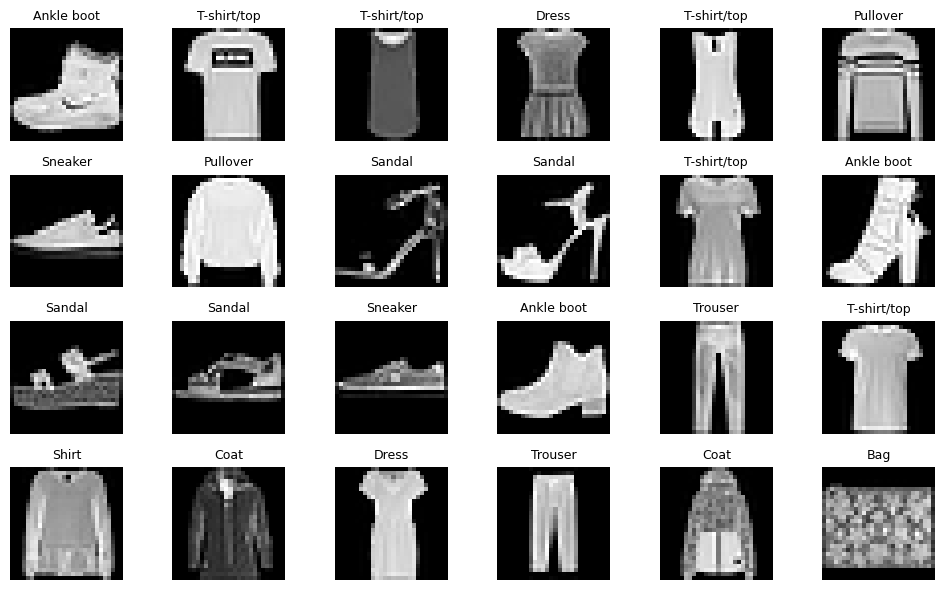

Saved sample image grid to: /content/cnn_fashion_mnist_project/artifacts/fashion_mnist_sample_grid.png


In [11]:
plt.figure(figsize=(10, 6))

for i in range(24):
    plt.subplot(4, 6, i + 1)
    plt.imshow(X_train_raw[i], cmap="gray")
    plt.title(class_names[int(y_train_raw[i])], fontsize=9)
    plt.axis("off")

plt.tight_layout()

sample_grid_path = ARTIFACT_DIR / "fashion_mnist_sample_grid.png"
plt.savefig(sample_grid_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved sample image grid to:", sample_grid_path)

##4.CELL PREPROCESSING FOR CNN TRAINING

**Explanation for Cell 4**

This cell preprocesses the images for CNN training. Pixel values are scaled from the original 0 to 255 range into the 0 to 1 range. The images are reshaped from 28 by 28 matrices into 28 by 28 by 1 tensors, where the final dimension represents the grayscale channel. The labels are converted into one-hot encoded vectors for multiclass classification.

In [12]:
X_train_scaled = X_train_raw.astype("float32") / 255.0
X_test_scaled = X_test_raw.astype("float32") / 255.0

X_train_scaled = np.expand_dims(X_train_scaled, axis=-1)
X_test_scaled = np.expand_dims(X_test_scaled, axis=-1)

y_train_onehot = keras.utils.to_categorical(y_train_raw, num_classes=10)
y_test_onehot = keras.utils.to_categorical(y_test_raw, num_classes=10)

X_train = X_train_scaled[:50000]
X_val = X_train_scaled[50000:]

y_train = y_train_raw[:50000]
y_val = y_train_raw[50000:]

y_train_encoded = y_train_onehot[:50000]
y_val_encoded = y_train_onehot[50000:]

X_test = X_test_scaled
y_test = y_test_raw
y_test_encoded = y_test_onehot

split_summary = {
    "training_samples": int(X_train.shape[0]),
    "validation_samples": int(X_val.shape[0]),
    "test_samples": int(X_test.shape[0]),
    "input_shape": list(X_train.shape[1:])
}

print(json.dumps(split_summary, indent=2))
print("Training tensor shape:", X_train.shape)
print("Validation tensor shape:", X_val.shape)
print("Test tensor shape:", X_test.shape)

{
  "training_samples": 50000,
  "validation_samples": 10000,
  "test_samples": 10000,
  "input_shape": [
    28,
    28,
    1
  ]
}
Training tensor shape: (50000, 28, 28, 1)
Validation tensor shape: (10000, 28, 28, 1)
Test tensor shape: (10000, 28, 28, 1)


##5.USING TENSORFLOW

**Explanation for Cell 5**

This cell creates TensorFlow datasets for training, validation, and testing. The training dataset is shuffled so that the model does not learn from the original order of examples. The data is batched so the CNN can process many images at once. Prefetching helps TensorFlow prepare the next batch while the current one is being processed.

In [13]:
BATCH_SIZE = 64

train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train, y_train_encoded))
    .shuffle(buffer_size=len(X_train), seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_val, y_val_encoded))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_test, y_test_encoded))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

for batch_X, batch_y in train_ds.take(1):
    print("Image batch shape:", batch_X.shape)
    print("Label batch shape:", batch_y.shape)

Image batch shape: (64, 28, 28, 1)
Label batch shape: (64, 10)


##6.BUILDING THE CONVOLUTIONAL NEURAL NETWORK

**Explanation for Cell 6**

This cell builds the convolutional neural network. The convolutional layers learn local visual filters. The max-pooling layers reduce spatial size while preserving important visual signals. The dense layers combine the learned image features into a final classification decision. The softmax output layer produces one probability for each fashion category.

In [14]:
def build_fashion_cnn(input_shape=(28, 28, 1), num_classes=10):
    model = keras.Sequential(
        [
            layers.Input(shape=input_shape),
            layers.Conv2D(
                filters=32,
                kernel_size=(3, 3),
                activation="relu",
                padding="same",
                name="conv_1"
            ),
            layers.MaxPooling2D(
                pool_size=(2, 2),
                name="max_pool_1"
            ),
            layers.Conv2D(
                filters=64,
                kernel_size=(3, 3),
                activation="relu",
                padding="same",
                name="conv_2"
            ),
            layers.MaxPooling2D(
                pool_size=(2, 2),
                name="max_pool_2"
            ),
            layers.Conv2D(
                filters=128,
                kernel_size=(3, 3),
                activation="relu",
                padding="same",
                name="conv_3"
            ),
            layers.Flatten(name="flatten_features"),
            layers.Dense(128, activation="relu", name="dense_1"),
            layers.Dropout(0.40, name="dropout_1"),
            layers.Dense(num_classes, activation="softmax", name="class_probabilities")
        ],
        name="fashion_mnist_convolutional_neural_network"
    )

    return model

model = build_fashion_cnn()
model.summary()

Model: "fashion_mnist_convolutional_neural_network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_1 (MaxPooling2D)       │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pool_2 (MaxPooling2D)       │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_features (Flatten)      │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ class_probabilities (Dense)     │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 896,906 (3.42 MB)

 Trainable params: 896,906 (3.42 MB)

 Non-trainable params: 0 (0.00 B)

##7.COMPILATION AND TRAINING

**Explanation for Cell 7**

This cell compiles and trains the CNN. The model uses categorical cross-entropy because there are ten possible fashion classes. The Adam optimizer adjusts the weights of the convolutional filters and dense layers. Early stopping restores the best validation model, reducing the risk of overfitting.

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=[early_stopping],
    verbose=1
)

history_dict = {
    key: [float(value) for value in values]
    for key, values in history.history.items()
}

history_path = ARTIFACT_DIR / "training_history.json"

with open(history_path, "w", encoding="utf-8") as f:
    json.dump(history_dict, f, indent=2)

print("Training history saved to:", history_path)

Epoch 1/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 94s 118ms/step - accuracy: 0.8171 - loss: 0.5118 - val_accuracy: 0.8845 - val_loss: 0.3092
Epoch 2/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 90s 115ms/step - accuracy: 0.8845 - loss: 0.3198 - val_accuracy: 0.9016 - val_loss: 0.2672
Epoch 3/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 90s 115ms/step - accuracy: 0.9031 - loss: 0.2693 - val_accuracy: 0.9122 - val_loss: 0.2362
Epoch 4/25
782/782 ━━━━━━━━━━━━━━━━━━━━ 88s 112ms/step - accuracy: 0.9163 - loss: 0.2340 - val_accuracy: 0.9127 - val_loss: 0.2302
Epoch 5/25
299/782 ━━━━━━━━━━━━━━━━━━━━ 51s 107ms/step - accuracy: 0.9201 - loss: 0.2080

##8.EVALUATION

**Explanation for Cell 8**

This cell evaluates the CNN training process and final test performance. The loss and accuracy curves show how the model learned across epochs. The test set provides the final estimate of generalization performance. The confusion matrix shows which fashion categories the model classifies well and which categories it tends to confuse.

In [ ]:
epochs_ran = range(1, len(history.history["loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history.history["loss"], label="Training loss")
plt.plot(epochs_ran, history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

loss_plot_path = ARTIFACT_DIR / "loss_curve.png"
plt.savefig(loss_plot_path, dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_ran, history.history["accuracy"], label="Training accuracy")
plt.plot(epochs_ran, history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

accuracy_plot_path = ARTIFACT_DIR / "accuracy_curve.png"
plt.savefig(accuracy_plot_path, dpi=150, bbox_inches="tight")
plt.show()

test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

y_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)

report_text = classification_report(
    y_test,
    y_pred,
    target_names=class_names
)

report_dict = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    output_dict=True
)

evaluation_summary = {
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "test_accuracy_manual": float(accuracy_score(y_test, y_pred)),
    "classification_report": report_dict,
    "confusion_matrix": cm.tolist()
}

evaluation_path = ARTIFACT_DIR / "evaluation_summary.json"

with open(evaluation_path, "w", encoding="utf-8") as f:
    json.dump(evaluation_summary, f, indent=2)

print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_accuracy, 4))
print("\nClassification report")
print(report_text)

plt.figure(figsize=(9, 8))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(np.arange(10), class_names, rotation=45, ha="right")
plt.yticks(np.arange(10), class_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=8)

confusion_matrix_path = ARTIFACT_DIR / "confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved evaluation summary to:", evaluation_path)

##9.VISUALIZATION

**Explanation for Cell 9**

This cell visualizes feature maps from the first convolutional layer. A feature map shows how one learned filter responds to the input image. This is one of the most important teaching moments in the notebook. Students can see that the CNN does not simply memorize the image. It transforms the image into many learned visual representations.

In [ ]:
sample_index = 0
sample_image = X_test[sample_index:sample_index + 1]
sample_label = class_names[int(y_test[sample_index])]

activation_model = keras.Model(
    inputs=model.inputs,
    outputs=model.get_layer("conv_1").output
)

activations = activation_model.predict(sample_image, verbose=0)

print("Sample true label:", sample_label)
print("Activation tensor shape:", activations.shape)

plt.figure(figsize=(3, 3))
plt.imshow(sample_image[0, :, :, 0], cmap="gray")
plt.title(f"Original image: {sample_label}")
plt.axis("off")

original_feature_input_path = ARTIFACT_DIR / "feature_map_original_input.png"
plt.savefig(original_feature_input_path, dpi=150, bbox_inches="tight")
plt.show()

number_of_feature_maps = min(16, activations.shape[-1])

plt.figure(figsize=(10, 10))

for i in range(number_of_feature_maps):
    plt.subplot(4, 4, i + 1)
    plt.imshow(activations[0, :, :, i], cmap="viridis")
    plt.title(f"Filter {i}", fontsize=9)
    plt.axis("off")

plt.tight_layout()

feature_map_path = ARTIFACT_DIR / "first_convolution_feature_maps.png"
plt.savefig(feature_map_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved original input image to:", original_feature_input_path)
print("Saved first convolution feature maps to:", feature_map_path)

##10.PREDICTIONS AND ERRORS

**Explanation for Cell 10**

This cell inspects concrete predictions and errors. Aggregate metrics are useful, but visual error analysis is more intuitive for students. The cell displays examples where the CNN made incorrect predictions and saves prediction records. This allows students to connect the confusion matrix to actual images.

In [ ]:
prediction_records = []

for i in range(len(y_test)):
    record = {
        "test_index": int(i),
        "true_label_id": int(y_test[i]),
        "true_label": class_names[int(y_test[i])],
        "predicted_label_id": int(y_pred[i]),
        "predicted_label": class_names[int(y_pred[i])],
        "predicted_probability": float(np.max(y_prob[i])),
        "correct": bool(y_pred[i] == y_test[i])
    }
    prediction_records.append(record)

predictions_path = ARTIFACT_DIR / "prediction_records.json"

with open(predictions_path, "w", encoding="utf-8") as f:
    json.dump(prediction_records, f, indent=2)

incorrect_indices = np.where(y_pred != y_test)[0]

print("Incorrect predictions:", len(incorrect_indices))
print("Prediction records saved to:", predictions_path)

if len(incorrect_indices) > 0:
    display_count = min(16, len(incorrect_indices))

    plt.figure(figsize=(12, 8))

    for plot_position, test_index in enumerate(incorrect_indices[:display_count]):
        plt.subplot(4, 4, plot_position + 1)
        plt.imshow(X_test[test_index, :, :, 0], cmap="gray")
        title_text = (
            "True: "
            + class_names[int(y_test[test_index])]
            + "\nPred: "
            + class_names[int(y_pred[test_index])]
        )
        plt.title(title_text, fontsize=8)
        plt.axis("off")

    plt.tight_layout()

    error_examples_path = ARTIFACT_DIR / "cnn_error_examples.png"
    plt.savefig(error_examples_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved error examples to:", error_examples_path)
else:
    print("The model made no errors on the test set.")

model_path = MODEL_DIR / "fashion_mnist_cnn.keras"
model.save(model_path)

print("Model saved to:", model_path)

##11.EXPLANATION AND VISUALIZATION

**Explanation for the LLM Results Cell**

This cell uses GPT-5.2 to explain the CNN model and its results. It reads the saved training history, evaluation summary, and prediction artifacts. The output is requested as strict JSON so that the explanation separates observed results, interpretation, limitations, and next steps. The API key is expected to be stored in Colab Secrets under OPENAI_API_KEY.

In [ ]:
import re
from google.colab import userdata
from openai import OpenAI

OPENAI_MODEL = "gpt-5.2"

api_key = userdata.get("OPENAI_API_KEY")

if not api_key:
    raise ValueError("OPENAI_API_KEY was not found in Colab Secrets.")

client = OpenAI(api_key=api_key)

with open(evaluation_path, "r", encoding="utf-8") as f:
    evaluation_for_llm = json.load(f)

with open(history_path, "r", encoding="utf-8") as f:
    history_for_llm = json.load(f)

with open(predictions_path, "r", encoding="utf-8") as f:
    predictions_for_llm = json.load(f)

incorrect_examples_for_llm = [
    record
    for record in predictions_for_llm
    if record["correct"] is False
][:20]

compact_results = {
    "run_id": RUN_ID,
    "dataset_summary": dataset_summary,
    "split_summary": split_summary,
    "model_name": model.name,
    "epochs_completed": len(history_for_llm["loss"]),
    "final_training_loss": history_for_llm["loss"][-1],
    "final_validation_loss": history_for_llm["val_loss"][-1],
    "final_training_accuracy": history_for_llm["accuracy"][-1],
    "final_validation_accuracy": history_for_llm["val_accuracy"][-1],
    "test_loss": evaluation_for_llm["test_loss"],
    "test_accuracy": evaluation_for_llm["test_accuracy"],
    "classification_report": evaluation_for_llm["classification_report"],
    "confusion_matrix": evaluation_for_llm["confusion_matrix"],
    "sample_incorrect_predictions": incorrect_examples_for_llm,
    "feature_map_artifact": str(feature_map_path)
}

system_prompt = """
You are a machine learning instructor.
Explain a convolutional neural network experiment for Fashion-MNIST.
Return strict JSON only.
Do not invent results.
Separate observed facts from interpretation.
"""

user_prompt = f"""
Analyze the following experiment results.

Return JSON with this schema:

{{
  "plain_english_summary": "string",
  "why_fashion_mnist_is_good_for_teaching_cnn": "string",
  "cnn_model_explanation": "string",
  "convolution_explanation": "string",
  "pooling_explanation": "string",
  "results_explanation": "string",
  "likely_confusions": ["string"],
  "what_feature_maps_show": "string",
  "evidence_used": ["string"],
  "assumptions": ["string"],
  "limitations": ["string"],
  "recommended_next_steps": ["string"],
  "verification_status": "Not verified by external data"
}}

Experiment results:

BEGIN_RESULTS_JSON
{json.dumps(compact_results, indent=2)}
END_RESULTS_JSON
"""

response = client.responses.create(
    model=OPENAI_MODEL,
    input=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
)

llm_text = response.output_text.strip()

def extract_json_object(text):
    text = text.strip()
    text = re.sub(r"^```json\s*", "", text)
    text = re.sub(r"^```\s*", "", text)
    text = re.sub(r"\s*```$", "", text)

    first = text.find("{")
    last = text.rfind("}")

    if first == -1 or last == -1 or last <= first:
        raise ValueError("No JSON object found in LLM response.")

    candidate = text[first:last + 1]
    return json.loads(candidate)

llm_explanation = extract_json_object(llm_text)

llm_explanation_path = ARTIFACT_DIR / "llm_results_explanation.json"

with open(llm_explanation_path, "w", encoding="utf-8") as f:
    json.dump(llm_explanation, f, indent=2)

print(json.dumps(llm_explanation, indent=2))
print("\nLLM explanation saved to:", llm_explanation_path)

##12.CONCLUSIONS

**Conclusion**

This notebook introduced convolutional neural networks through the Fashion-MNIST classification problem. Fashion-MNIST is a strong teaching dataset because it preserves the simplicity of the original MNIST format while offering a richer visual classification task. Instead of recognizing handwritten digits, the model must distinguish clothing categories such as shirts, trousers, coats, sandals, sneakers, bags, and ankle boots. These categories are visually more subtle than digits, which makes the dataset more appropriate for explaining why convolutional layers are useful.

The central lesson is that images are not just collections of independent pixels. Images have spatial structure. Neighboring pixels form edges, curves, textures, contours, and shapes. A fully connected network can process image pixels numerically, but it does not naturally preserve the local geometry of the image. A convolutional neural network is designed precisely for this kind of data. It applies learned filters to local regions of the image and reuses those filters across different spatial positions. This allows the model to detect visual patterns wherever they appear.

The notebook followed a complete experimental workflow. It began by setting up the environment and recording a run manifest. It then loaded the Fashion-MNIST dataset, visualized sample images, scaled pixel values, reshaped the data into image tensors, and constructed TensorFlow datasets. The model architecture introduced the basic CNN pattern: convolution, pooling, convolution, pooling, deeper convolution, flattening, dense classification, dropout regularization, and softmax output. This sequence gives students a clear first view of how modern image classifiers are assembled.

The training and evaluation cells showed how the CNN learned from data. The loss and accuracy curves helped students compare training and validation behavior. The test evaluation provided a final measure of generalization. The classification report and confusion matrix added more detail by showing performance class by class. This is important because image classifiers rarely make errors uniformly. In Fashion-MNIST, visually similar categories are often more difficult to separate. For example, shirts, T-shirts, pullovers, and coats may be confused because they share broad upper-body shapes. Sneakers, sandals, and ankle boots may also create boundary cases depending on the image.

The feature-map visualization cell is especially important for teaching. It shows the activations produced by the first convolutional layer for a sample image. These feature maps help students see that the CNN transforms the original image into many learned visual channels. Each filter responds differently to the same input. Some filters may highlight edges, others may respond to contours, and others may activate around broader visual regions. This makes the convolutional process more concrete and less mysterious.

The final LLM explanation cell extends the notebook into the governed workflow used throughout this project. The neural network produces numerical results and visual artifacts. The language model explains those results in structured JSON. This creates a clear separation between computation, interpretation, assumptions, limitations, and recommended next steps.

Fashion-MNIST therefore makes excellent sense as the first CNN teaching example. It is simple enough for students to run in Colab, visual enough to support intuition, and realistic enough to demonstrate the value of convolution. It teaches the transition from ordinary dense networks to spatially aware deep learning models.